In [183]:
%load_ext autoreload
%autoreload 2

import jax.numpy as jnp
from mGST.reporting.reporting import generate_basis_labels
from mGST.compatibility import std2pp
import matplotlib.pyplot as plt

from mGST.taxonomy import pauli_to_symplectic, symplectic_inner_product, commutation_relation, walsh_hadamard_transform_symplectic, walsh_hadamard_transform_2n_basis, walsh_hadamard_transform_local_basis, weight_histogram, plot_weight_histogram, plot_pauli_probabilities_labeled, plot_pauli_probabilities_indexed

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load operators

In [5]:
ops_gauge_opt = jnp.load("data/ops_gauge_optimized_mgst_4q_rank_4_all.npz")
ops_target = jnp.load("data/ops_target_mgst_4q_rank_4_all.npz")
ops_gauge_opt.keys(), ops_target.keys()

(KeysView(NpzFile 'data/ops_gauge_optimized_mgst_4q_rank_4_all.npz' with keys: kraus, povm, state),
 KeysView(NpzFile 'data/ops_target_mgst_4q_rank_4_all.npz' with keys: kraus, povm, state))

# Eigenvalues

In [6]:
num_qubits = 4
dim = 2**num_qubits

gate_labels = {0: 'Rx(pi/2)',
 1: 'Rx(pi/2)',
 2: 'Rx(pi/2)',
 3: 'Rx(pi/2)',
 4: 'Ry(pi/2)',
 5: 'Ry(pi/2)',
 6: 'Ry(pi/2)',
 7: 'Ry(pi/2)',
 8: 'CZ-CZ'}

pauli_labels = generate_basis_labels(pdim=dim, basis="Pauli")
len(pauli_labels)

256

In [12]:
kraus_target_pauli, *_ = std2pp(*ops_target.values())
# Convert to pauli basis
kraus_gauge_opt_pauli, *_ = std2pp(*ops_gauge_opt.values())

# Looking only at the last gate (CZ-CZ)
cz_cz_gauge_pauli = kraus_gauge_opt_pauli[-1]
cz_cz_target_pauli = kraus_target_pauli[-1]

cz_cz_gauge_pauli.shape, cz_cz_target_pauli.shape

((256, 256), (256, 256))

In [36]:
pauli_eigenvals_vector = jnp.diag(cz_cz_gauge_pauli)
# what is the sum of its eigenvalues?
jnp.sum(pauli_eigenvals_vector), jnp.linalg.norm(pauli_eigenvals_vector.imag)

(Array(15.98531366+0.j, dtype=complex128), Array(0., dtype=float64))

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


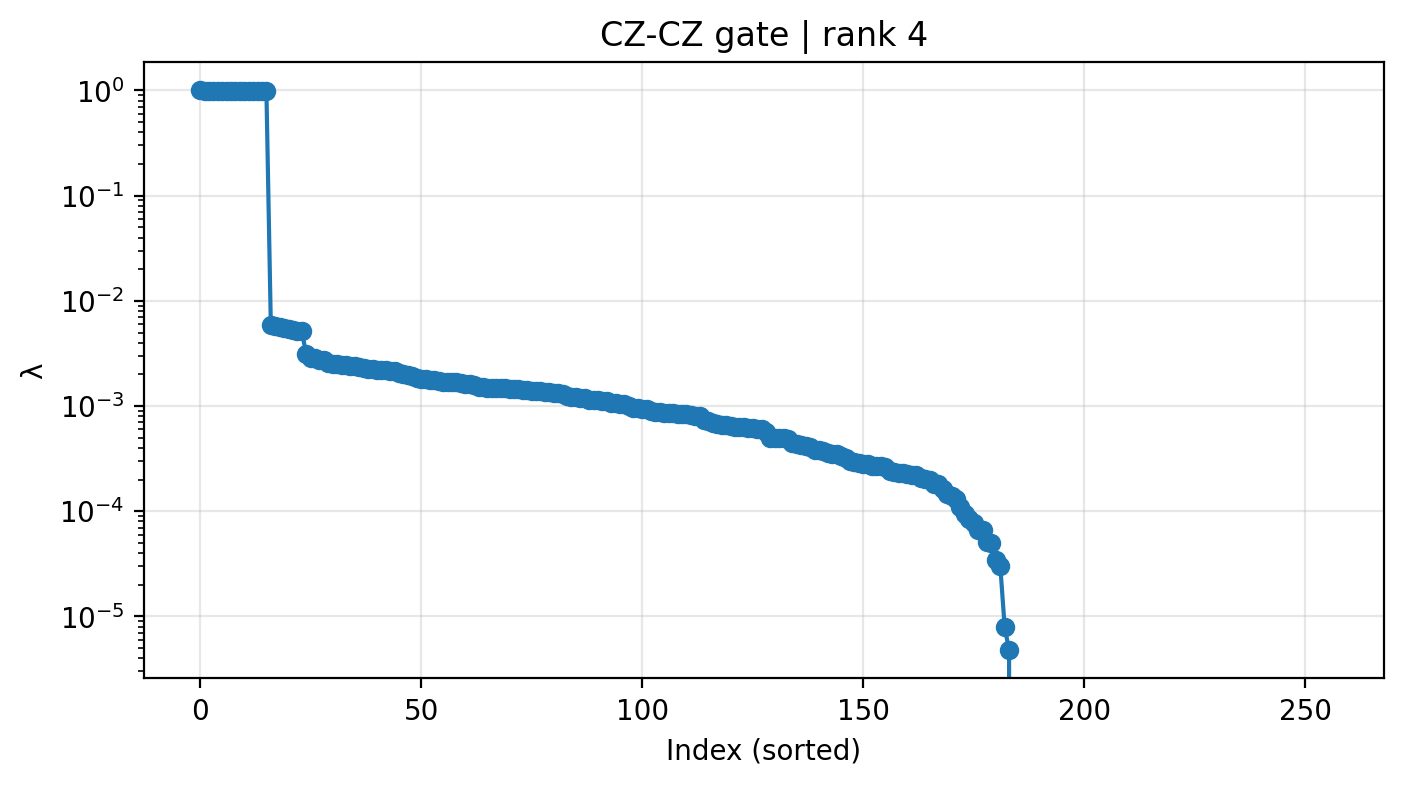

In [89]:
# plotting the eigenvalues
plt.figure(figsize=(8,4), dpi=200)
plt.semilogy(jnp.sort(pauli_eigenvals_vector, descending=True), "o-")
plt.xlabel("Index (sorted)")
plt.ylabel("λ")
plt.title("CZ-CZ gate | rank 4")
plt.grid(alpha=0.3)
plt.show()


# Probabilties

In [154]:
label_1 = "IIXI"
label_2 = "YZZZ"

s1 = pauli_to_symplectic(label_1)
s2 = pauli_to_symplectic(label_2)
symplectic_inner_product(s1, s2)

1

In [155]:
commutation_relation(label_1, label_2)

1

In [150]:
probabilities_dct = walsh_hadamard_transform_symplectic(eigenvalues=pauli_eigenvals_vector.real, pauli_labels=pauli_labels)
probabilities = jnp.array(list(probabilities_dct.values()))

In [151]:
sum(probabilities)

Array(1., dtype=float64)

In [152]:
probabilities_test = walsh_hadamard_transform_2n_basis(pauli_eigenvals_vector.real)
jnp.sum(probabilities_test)

Array(1., dtype=float64)

In [156]:
result_test = walsh_hadamard_transform_local_basis(pauli_eigenvals_vector.real, pauli_labels)
probabilities_test_2 = jnp.array(list(result_test.values()))

In [157]:
jnp.allclose(jnp.sort(probabilities), jnp.sort(probabilities_test)) # not the same if they are not sorted.

Array(True, dtype=bool)

In [158]:
jnp.allclose(probabilities, probabilities_test) # not the same if they are not sorted.

Array(False, dtype=bool)

In [159]:
jnp.allclose(probabilities, probabilities_test_2)

Array(True, dtype=bool)

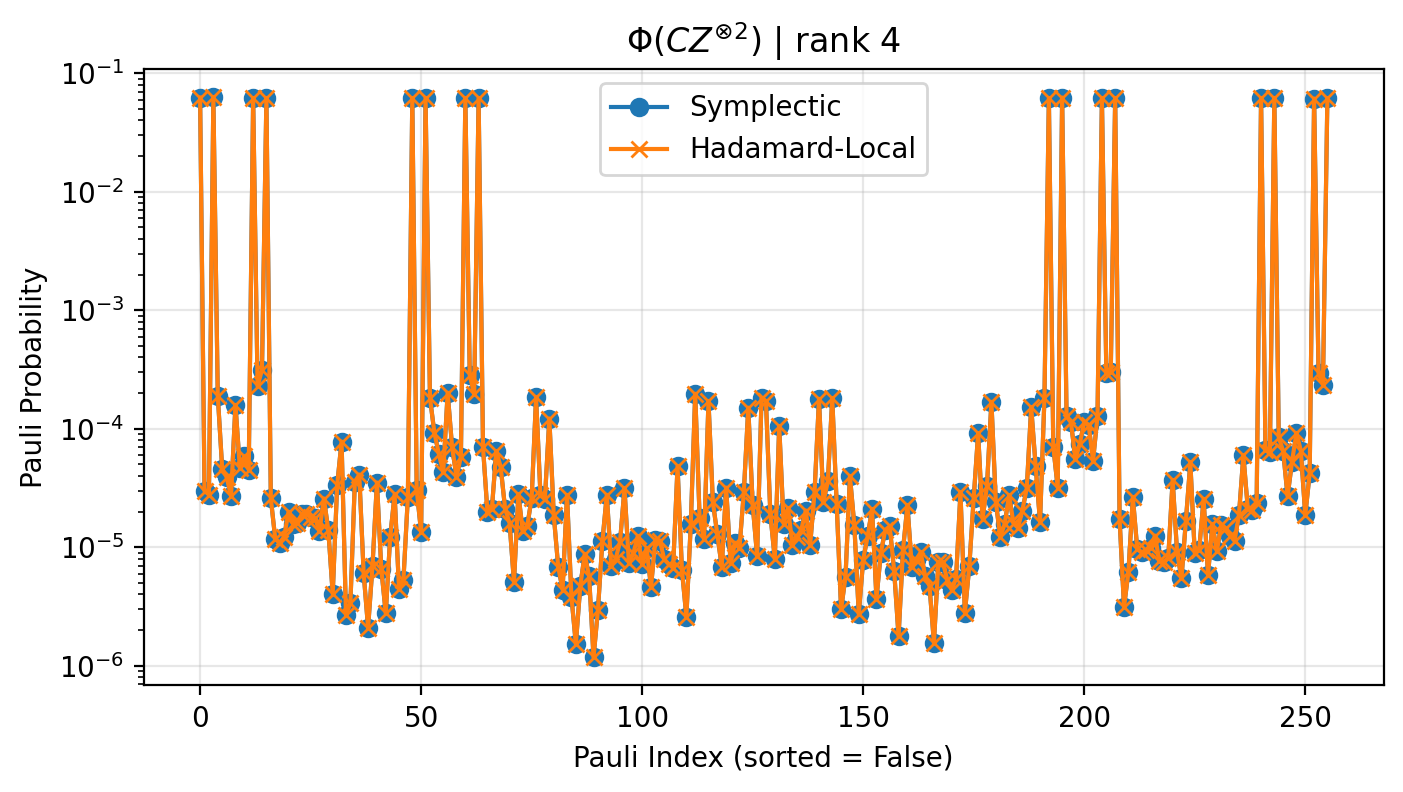

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [208]:
probabilities_by_methods = {
    "Symplectic": probabilities,
    # "Hadamard-Global": probabilities_test,
    "Hadamard-Local": probabilities_test_2
}
title_cz_cz = r"$\Phi(CZ^{\otimes 2})$ | rank 4"
plot_pauli_probabilities_indexed(probabilities=probabilities_by_methods, title=title_cz_cz)


In [135]:
hadamard = jnp.array([[1, 1], [1, -1]])
jnp.kron(hadamard, hadamard)

Array([[ 1,  1,  1,  1],
       [ 1, -1,  1, -1],
       [ 1,  1, -1, -1],
       [ 1, -1, -1,  1]], dtype=int64)

# Histogram

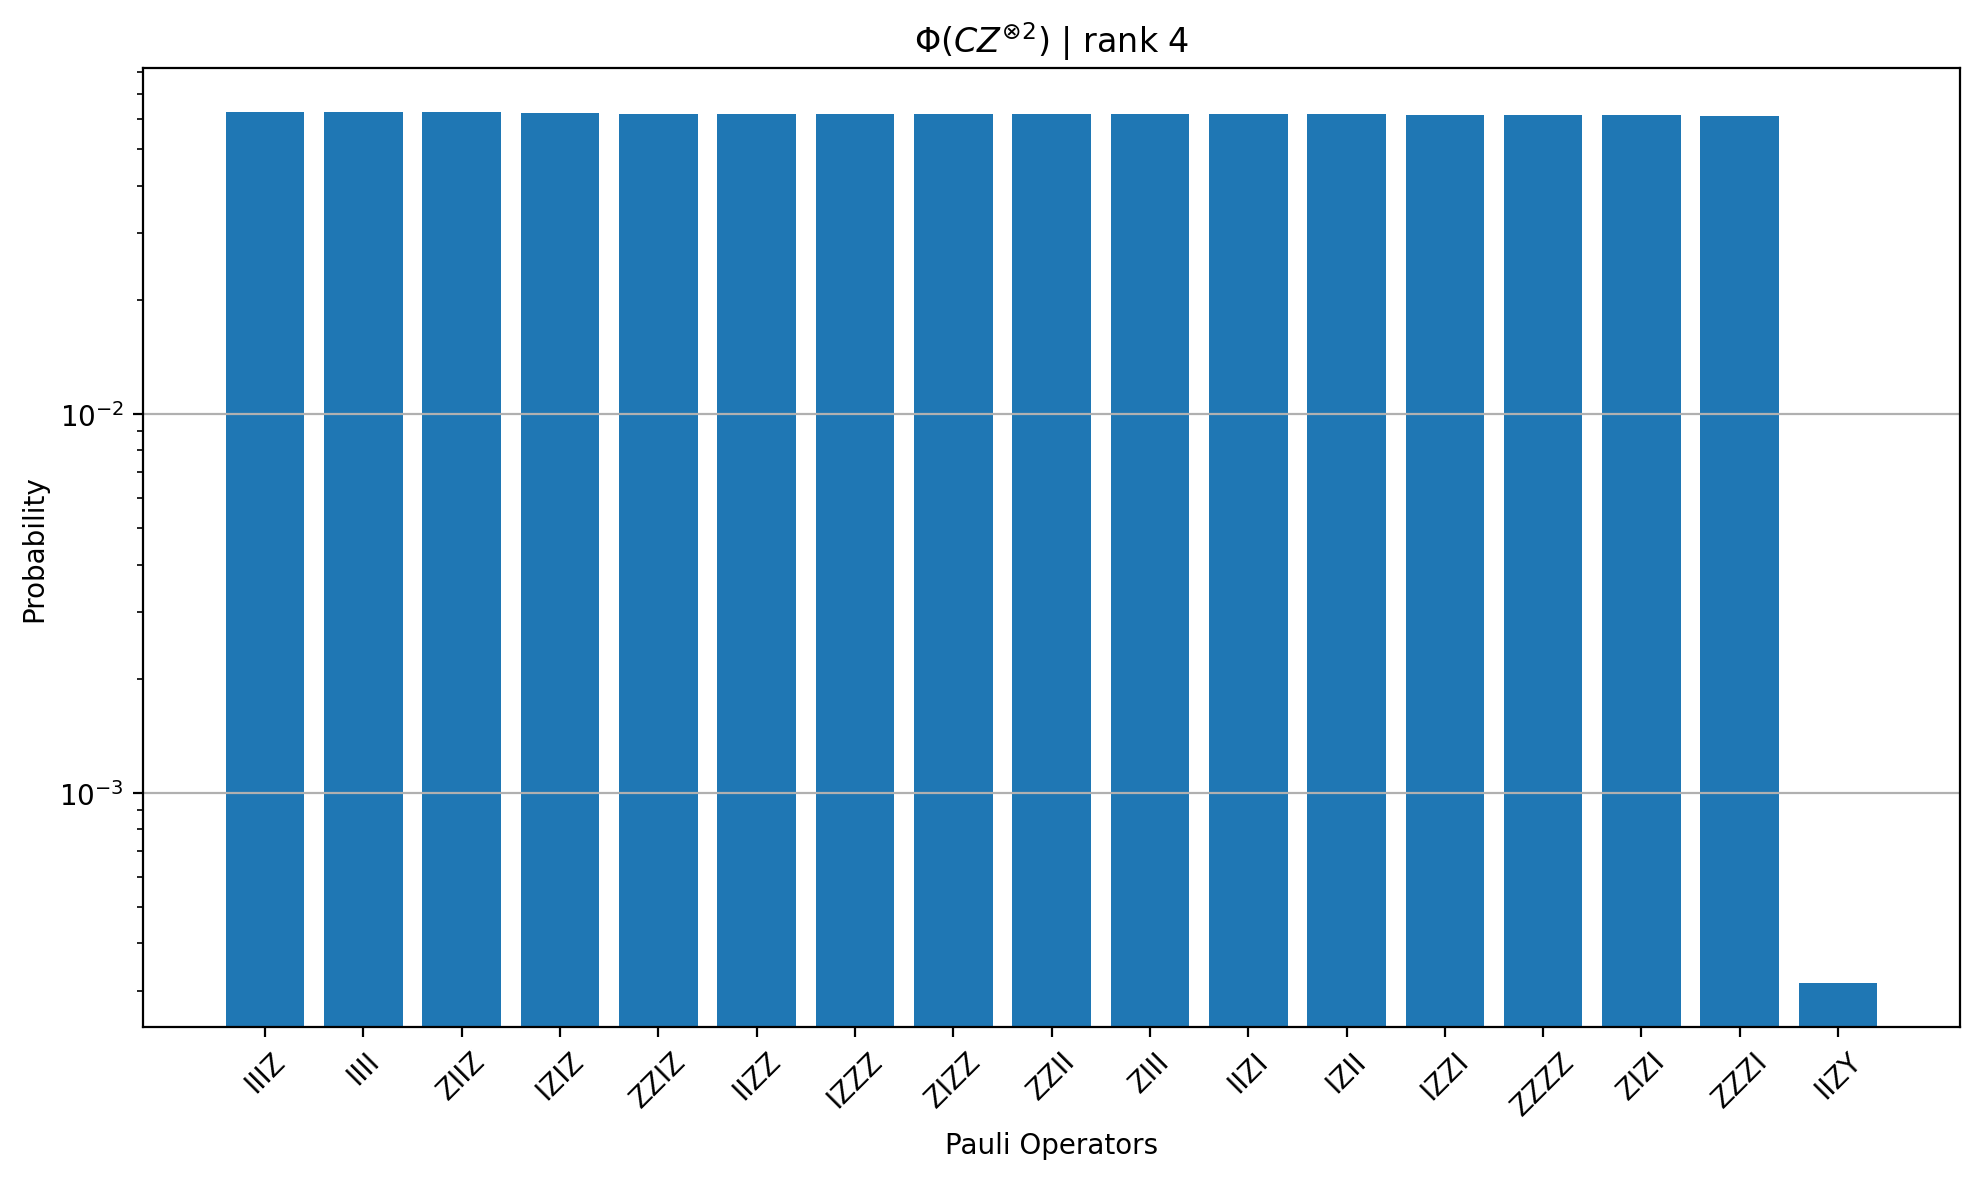

In [209]:
plot_pauli_probabilities_labeled(probabilities=probabilities_dct, max_num_labels=17, log_scale=True, title=title_cz_cz)

In [163]:
weights = weight_histogram(probabilities_dct, normalize=True)
weights

Total probability: 1.0


{0: Array(0.06244263, dtype=float64),
 1: Array(0.2483852, dtype=float64),
 2: Array(0.37423192, dtype=float64),
 3: Array(0.2515095, dtype=float64),
 4: Array(0.06343074, dtype=float64)}

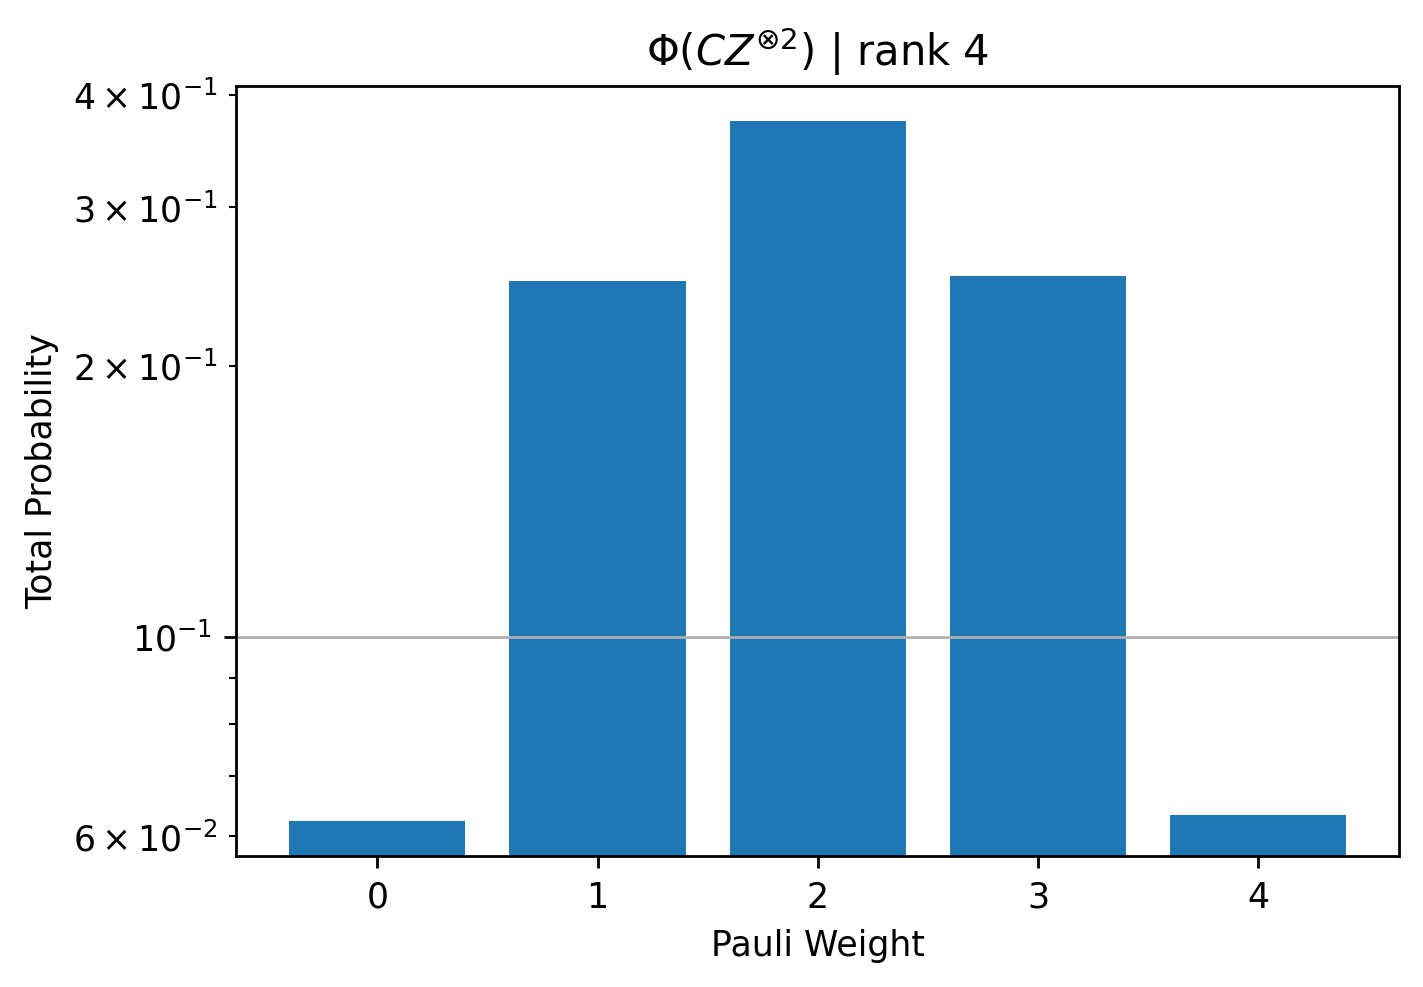

<Figure size 640x480 with 0 Axes>

In [210]:
figure_weights = plot_weight_histogram(weights, ascending=True, title=title_cz_cz)

# Now for the effective error channel

In [194]:
cz_cz_target_pauli_inv = jnp.linalg.inv(cz_cz_target_pauli)
error_ptm = cz_cz_gauge_pauli @ cz_cz_target_pauli_inv
error_ptm_eigenvals = jnp.diag(error_ptm)
probabilities_dict_error = walsh_hadamard_transform_local_basis(error_ptm_eigenvals.real, pauli_labels)
probabilties_error = jnp.array(list(probabilities_dict_error.values()))

2026-04-09 14:49:01,511 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 14:49:01,587 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


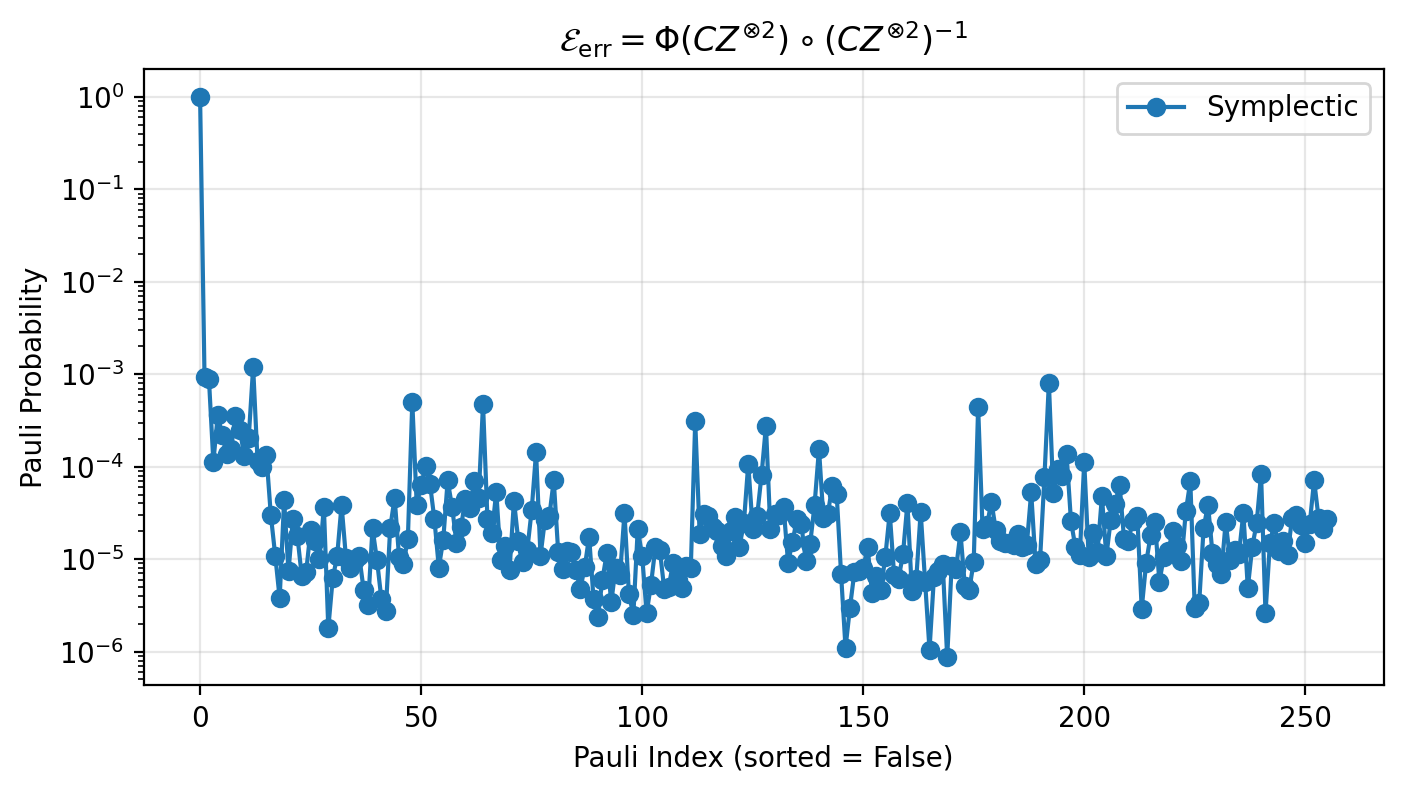

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [219]:
title_error = r"$\mathcal{E}_{\mathrm{err}}  = \Phi(CZ^{\otimes 2}) \circ (CZ^{\otimes 2})^{-1} $"
plot_pauli_probabilities_indexed(probabilities={"Symplectic": probabilties_error}, title=title_error)

2026-04-09 14:49:05,798 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 14:49:05,857 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


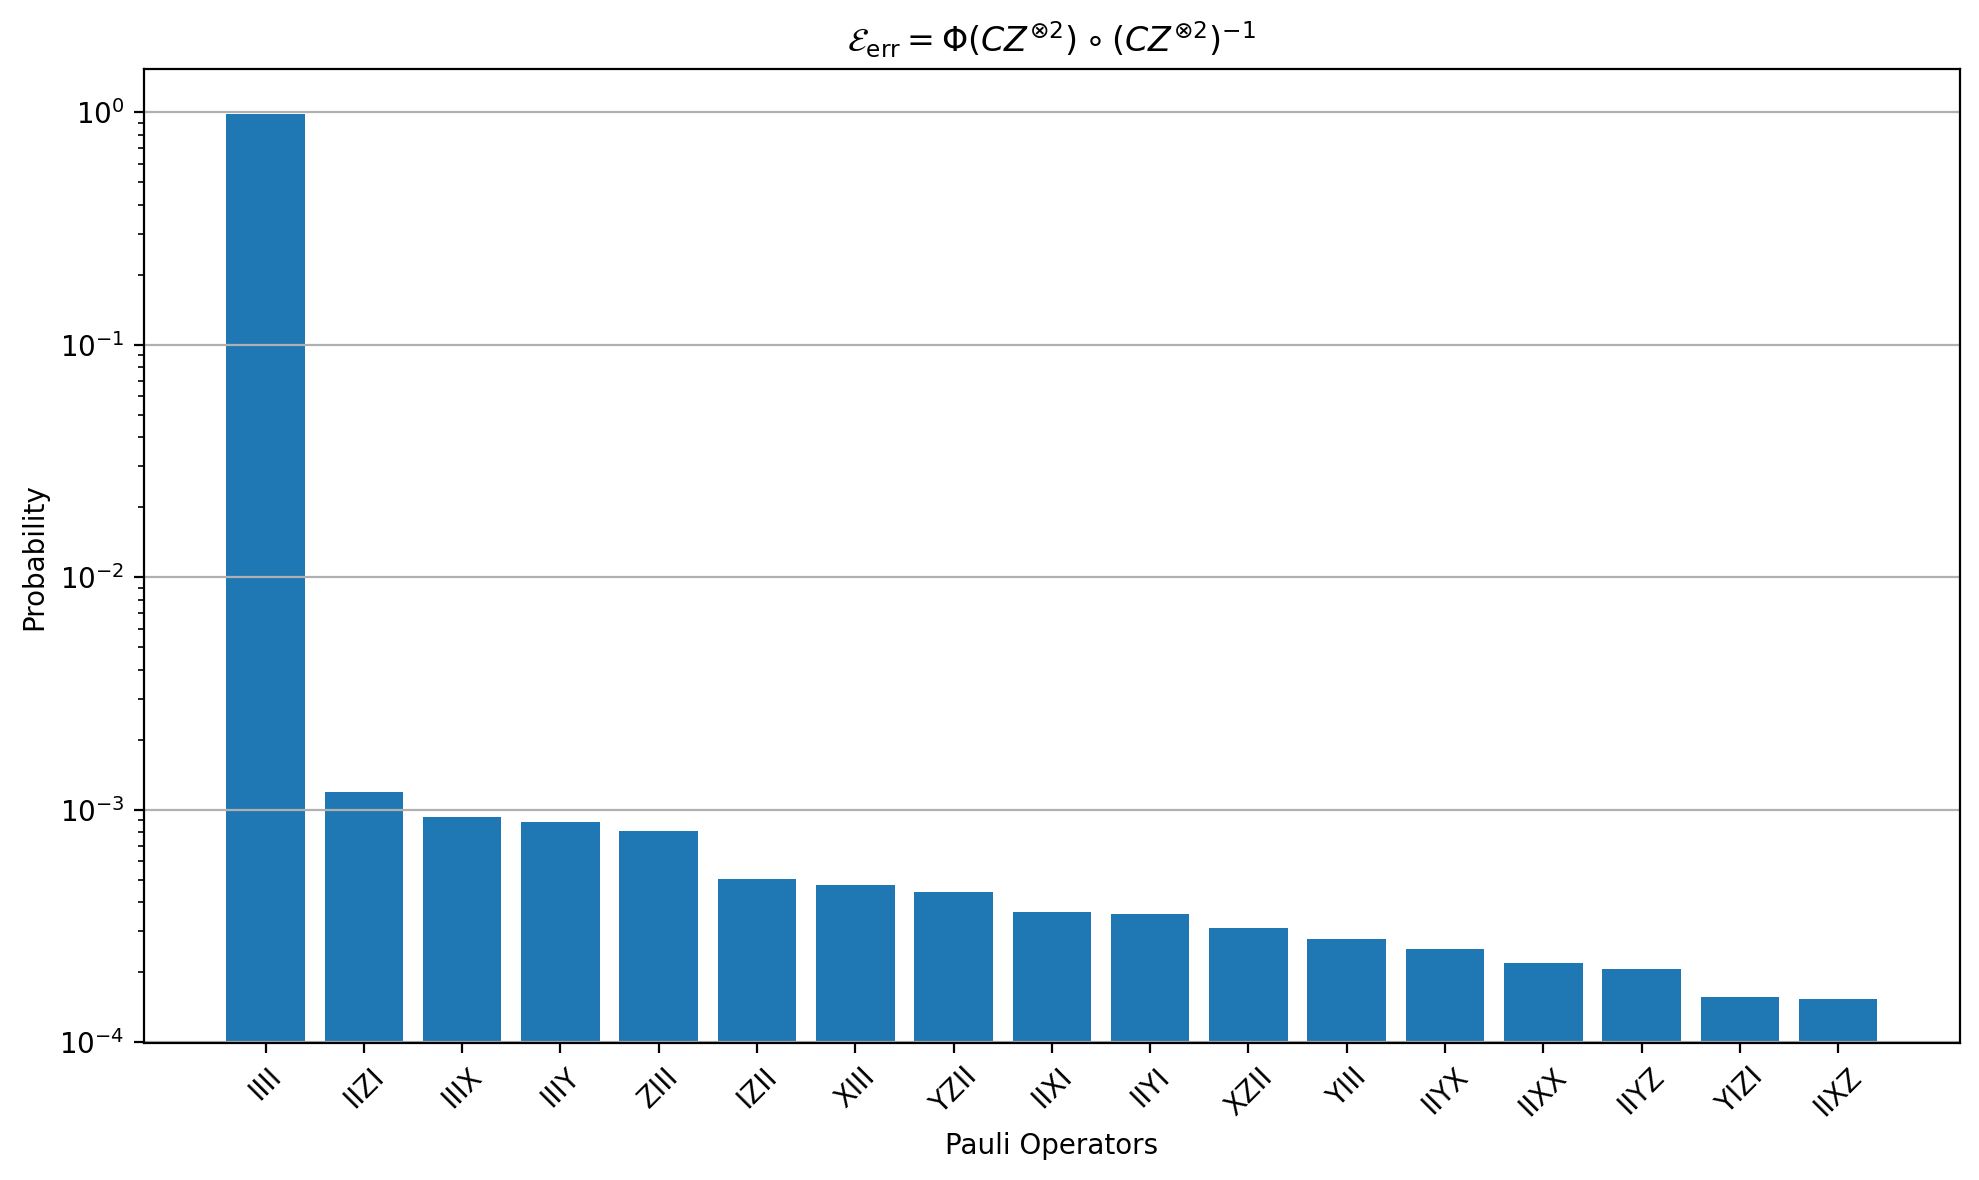

In [220]:
plot_pauli_probabilities_labeled(probabilities=probabilities_dict_error, max_num_labels=17, log_scale=True, title=title_error)

2026-04-09 14:49:06,623 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 14:49:06,664 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


Total probability: 1.0000000000000004


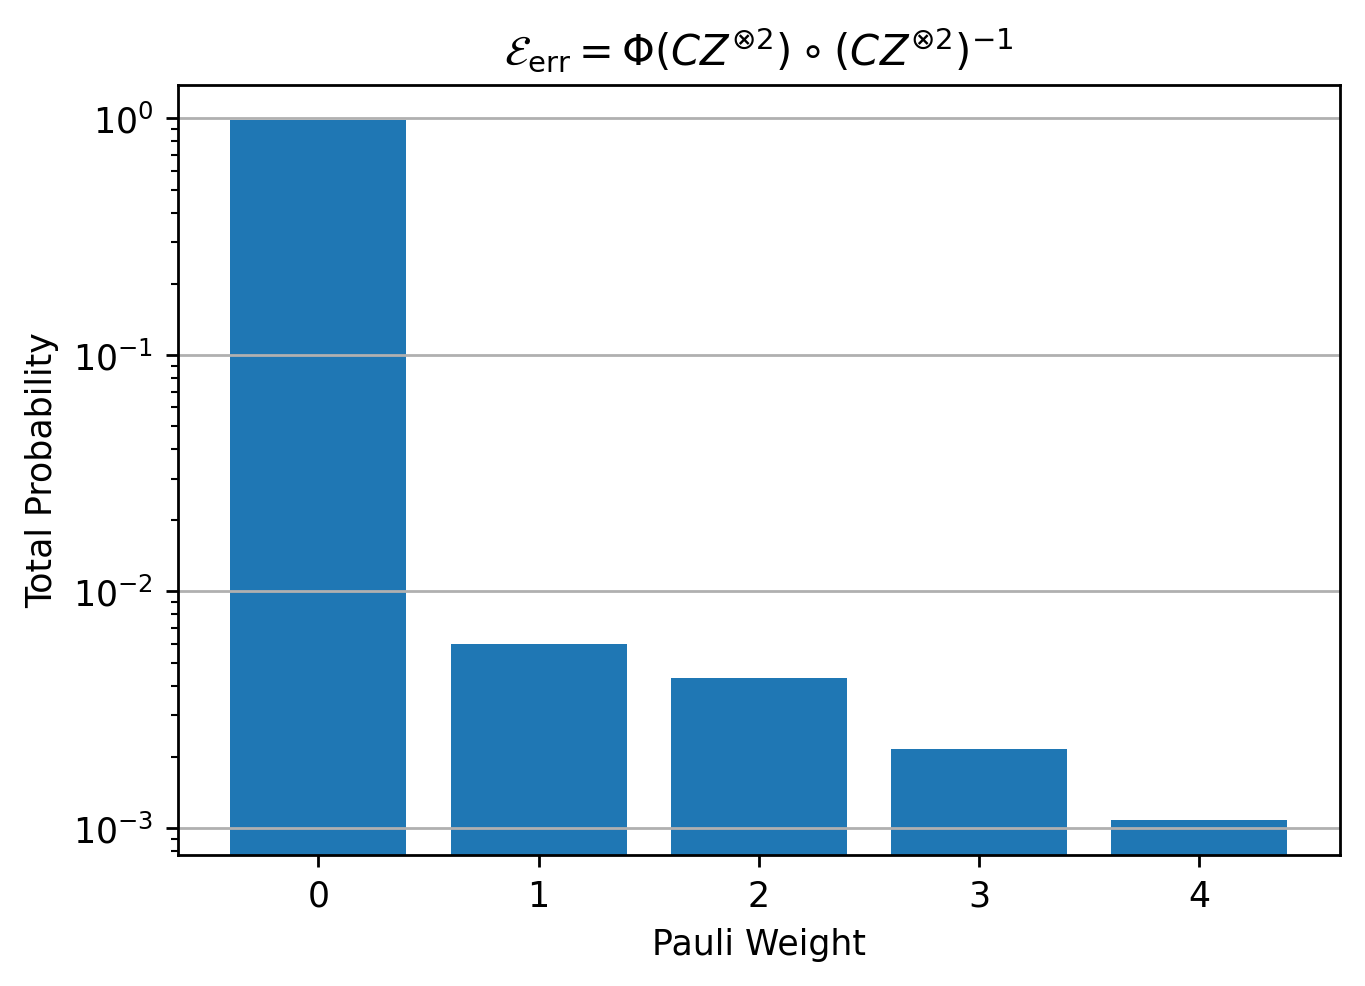

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [221]:
weights_error = weight_histogram(probabilities_dict_error, normalize=True)
plot_weight_histogram(weights_error, ascending=True, title=title_error)

2026-04-09 14:59:12,657 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode
2026-04-09 14:59:12,679 - matplotlib.mathtext - INFO - Substituting symbol E from STIXNonUnicode


Total probability: 0.013501385977892882


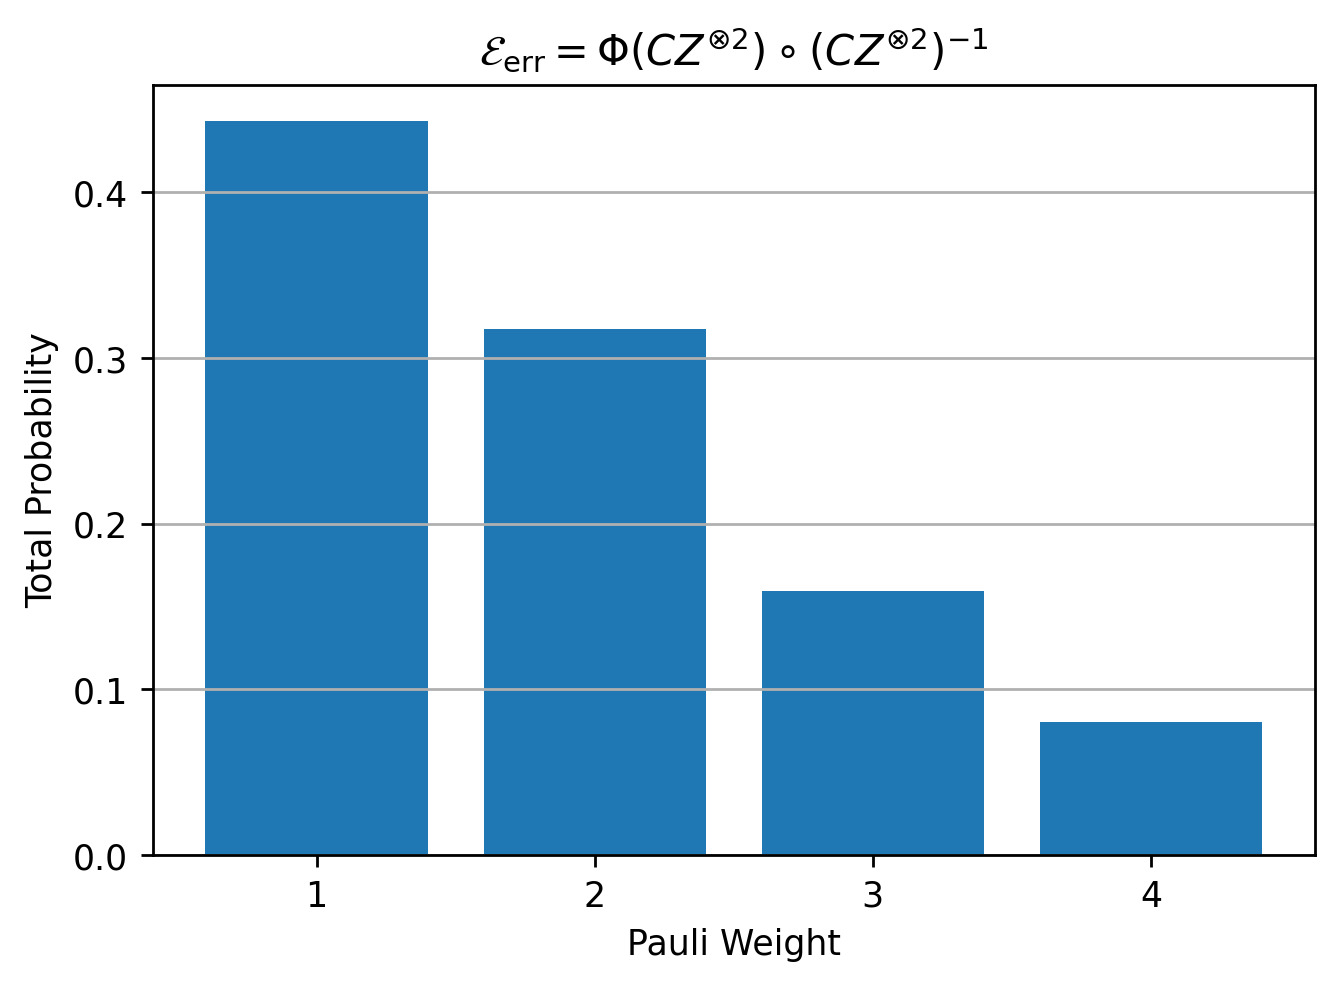

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [224]:
# look only at the error components.
weights_only_error = weight_histogram(probabilities_dict_error, normalize=True, exclude_identity=True)
plot_weight_histogram(weights_only_error, ascending=True, title=title_error, log_scale=False)